# Entrega Clustering Grupo 16

Integrantes:
- Eduardo Montecinos
- Jose Cristobal Silva
- Matías Toledo

In [1]:
library(cluster)
library(factoextra)
options(scipen = 999)

Warning message:
"package 'cluster' was built under R version 4.4.3"
Warning message:
"package 'factoextra' was built under R version 4.4.3"
Loading required package: ggplot2

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



## Ejercicio 1:
### De acuerdo al gráfico obtenido, cuál es el valor de K mas apropiado? Explique su decisión.

      V1    V2    V3    V4    V5    V6
1  16.63 15.46 6.053 3.465 2.040 5.877
2  20.03 16.90 6.493 3.857 3.063 6.320
3  15.60 15.11 5.832 3.286 2.725 5.752
4  10.82 12.83 5.180 2.630 4.853 5.089
5  14.79 14.52 5.545 3.291 2.704 5.111
6  14.03 14.16 5.438 3.201 1.717 5.001
7  16.44 15.25 5.884 3.505 1.969 5.533
8  13.78 14.06 5.479 3.156 3.136 4.872
9  18.76 16.20 6.172 3.796 3.120 6.053
10 12.88 13.50 5.139 3.119 2.352 4.607


       V1              V2              V3              V4       
 Min.   :10.59   Min.   :12.41   Min.   :4.899   Min.   :2.630  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:5.262   1st Qu.:2.944  
 Median :14.36   Median :14.32   Median :5.524   Median :3.237  
 Mean   :14.85   Mean   :14.56   Mean   :5.629   Mean   :3.259  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:5.980   3rd Qu.:3.562  
 Max.   :21.18   Max.   :17.25   Max.   :6.675   Max.   :4.033  
       V5              V6       
 Min.   :0.765   Min.   :4.519  
 1st Qu.:2.562   1st Qu.:5.045  
 Median :3.599   Median :5.223  
 Mean   :3.700   Mean   :5.408  
 3rd Qu.:4.769   3rd Qu.:5.877  
 Max.   :8.456   Max.   :6.550  

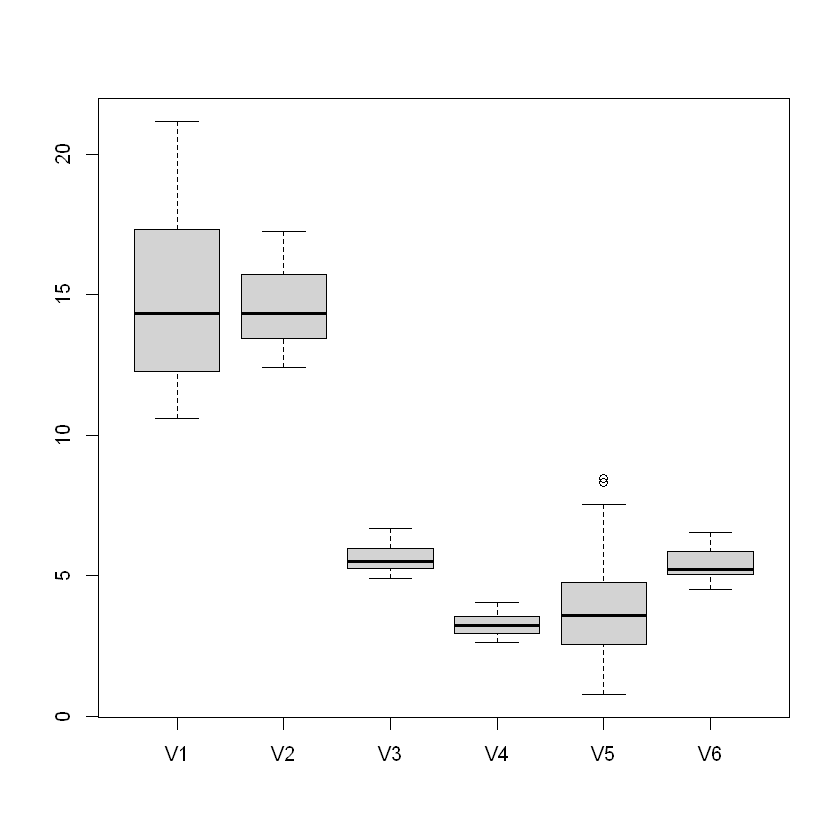

In [2]:
# Carga datos Ejercicio 1
#ruta datos
#lee datos del archivo de texto como una matriz. La primera #columna se utiliza como vector de nombres de las filas
datos1 <- read.table("semillas1.txt", dec = ".")

print(datos1[1:10,])
summary(datos1)
boxplot(datos1)

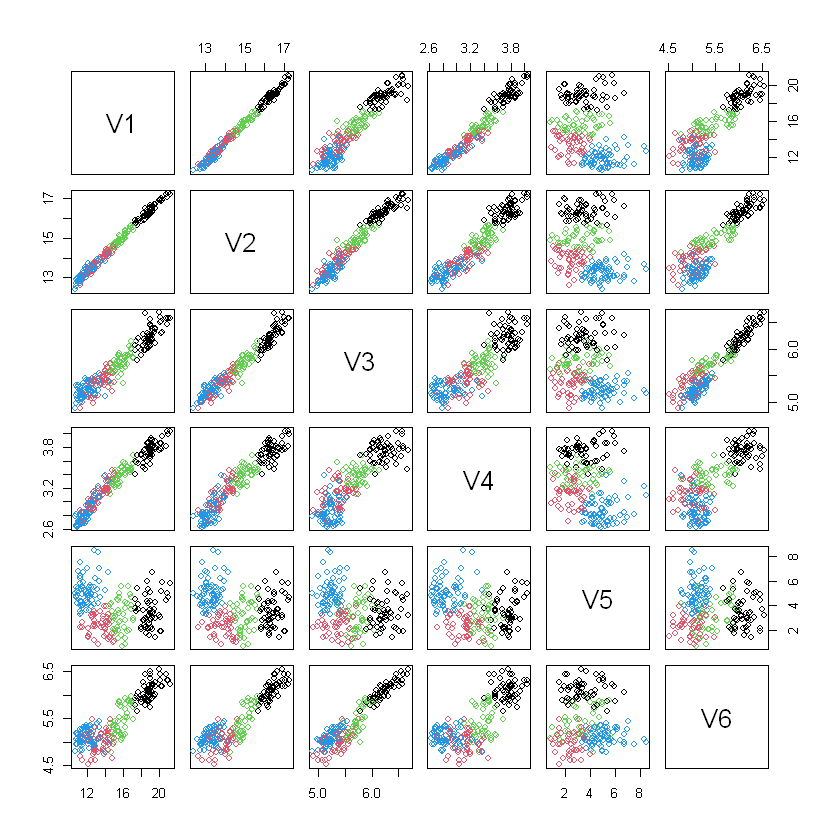

In [3]:
#ingresar valor de k0 
k0=4
cl<-kmeans(datos1,k0,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(datos1,col=cl$cluster)

Call:
princomp(x = datos1, cor = TRUE)

Standard deviations:
    Comp.1     Comp.2     Comp.3     Comp.4     Comp.5     Comp.6 
2.16788117 1.00229308 0.49446476 0.20713724 0.08426551 0.03461094 

 6  variables and  210 observations.


,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
1,3.0936321,-0.2499533,-0.04446158,-0.04386905,0.0115749668,0.013458399
2,-1.1731198,1.0501576,0.10256003,0.05800065,-0.0041432679,0.001410480
3,0.6362517,0.3177031,0.12251442,0.05021075,-0.0084876163,-0.025890456
4,-2.1376924,-0.7392228,-0.11677986,-0.03800567,-0.0009242843,0.005265824


K-means clustering with 4 clusters of sizes 54, 46, 44, 66

Cluster means:
        V1       V2       V3       V4       V5       V6
1 18.96296 16.39667 6.242722 3.749926 3.540333 6.100778
2 13.39109 13.86522 5.366000 3.114283 2.415804 4.990674
3 15.71909 14.97659 5.745182 3.398500 3.187045 5.448386
4 11.91439 13.26152 5.231227 2.863939 5.068288 5.105348

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  3   1   3   4   3   2   3   2   1   2   4   3   3   3   1   4   4   3   3   4 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
  4   1   3   4   4   3   4   2   2   1   3   2   4   3   1   1   1   4   3   4 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  2   4   1   2   4   1   1   4   4   4   1   2   3   4   3   2   3   3   1   4 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
  2   1   2   3   1   2   1   3   1   4   1   2   3   1   

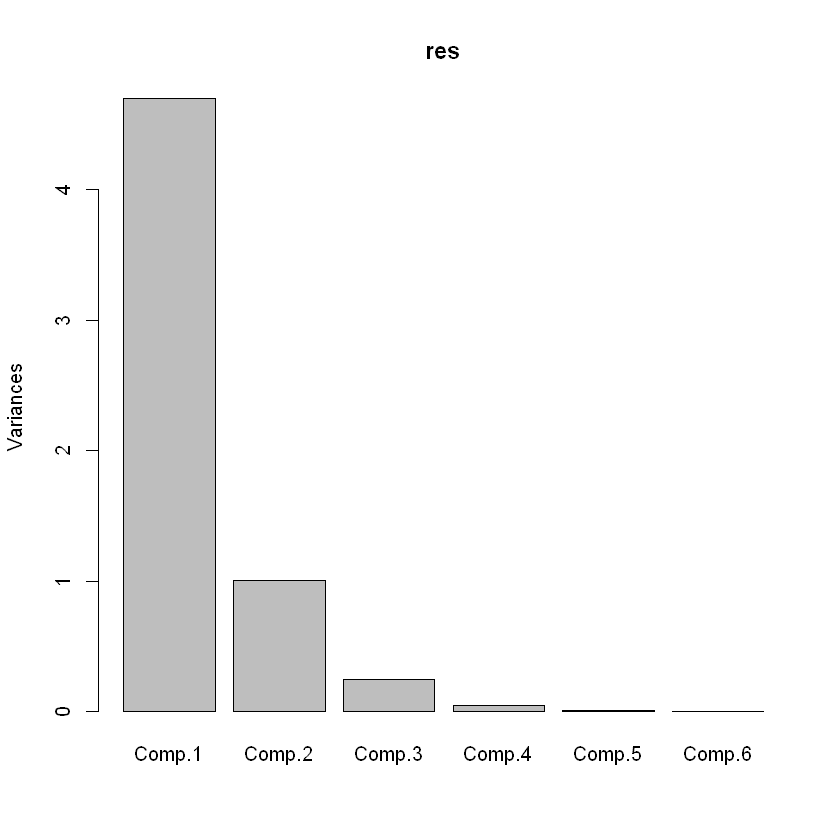

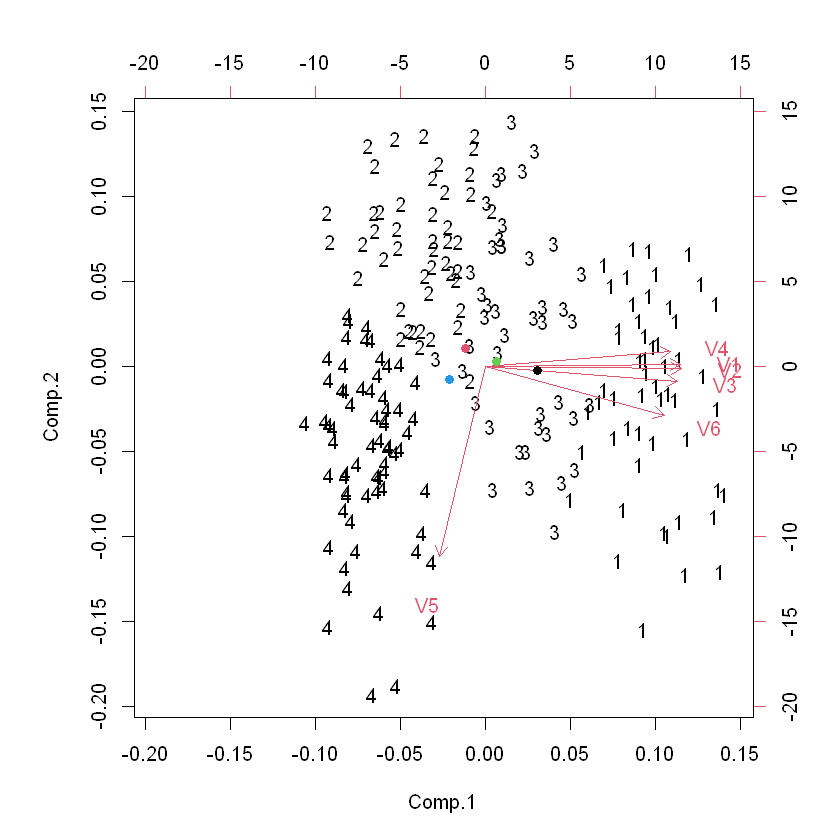

In [4]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos1, cor=TRUE)
print(res)
plot(res)
res2 <- predict(res,cl$centers)
res2
cl
biplot(res,xlabs=cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:k0,pch=19)

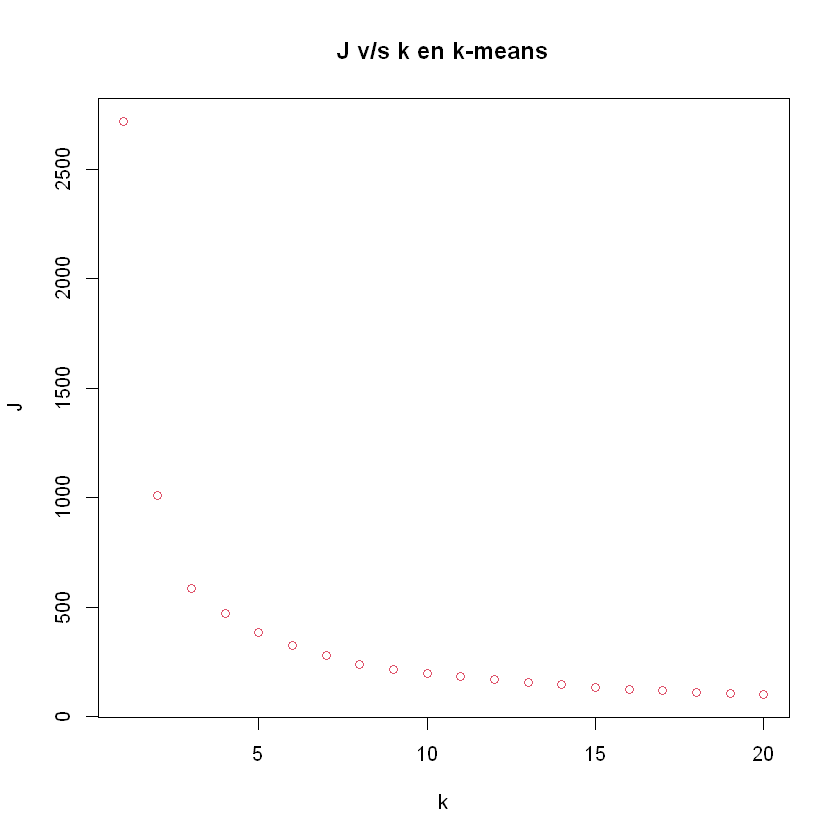

In [5]:
#Estrategia para elegir K, el numero de grupos
#J suma cuadrado de las distancias por cada k utilizado
#K-means
J<-rep(0,20)
fin_iter<-20


for (k in 1:fin_iter){
     cl<-kmeans(datos1,k,iter.max=1000,nstart=10)
	 J[k]<-cl$tot.withinss
}


plot(1:fin_iter,J,xlab="k",ylab="J",type="p",main="J v/s k en k-means",col=2) 

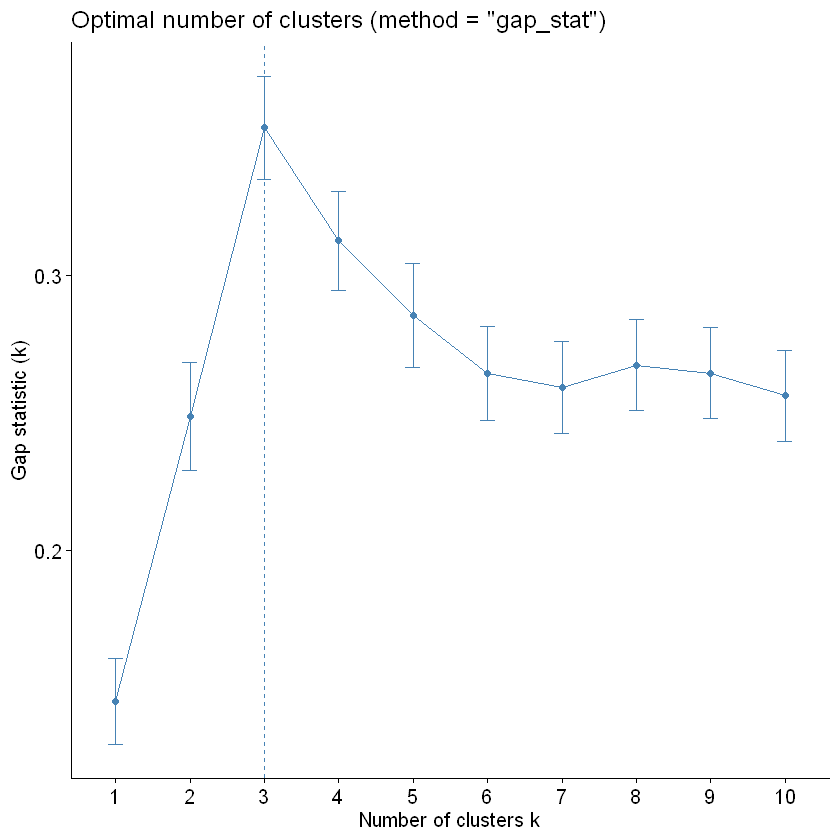

In [6]:
df1 <- data.frame(datos1)
gap_stat <- clusGap(df1,
                    FUN = kmeans,
                    nstart = 25,
                    K.max = 10,
                    B = 50)


fviz_gap_stat(gap_stat)

K = 3 es el óptimo por codo y gap_stat

## Pregunta 2
### Realice nuevamente los cálculos con el K óptimo y  caracterice los grupos obtenidos. Interprete sus resultados

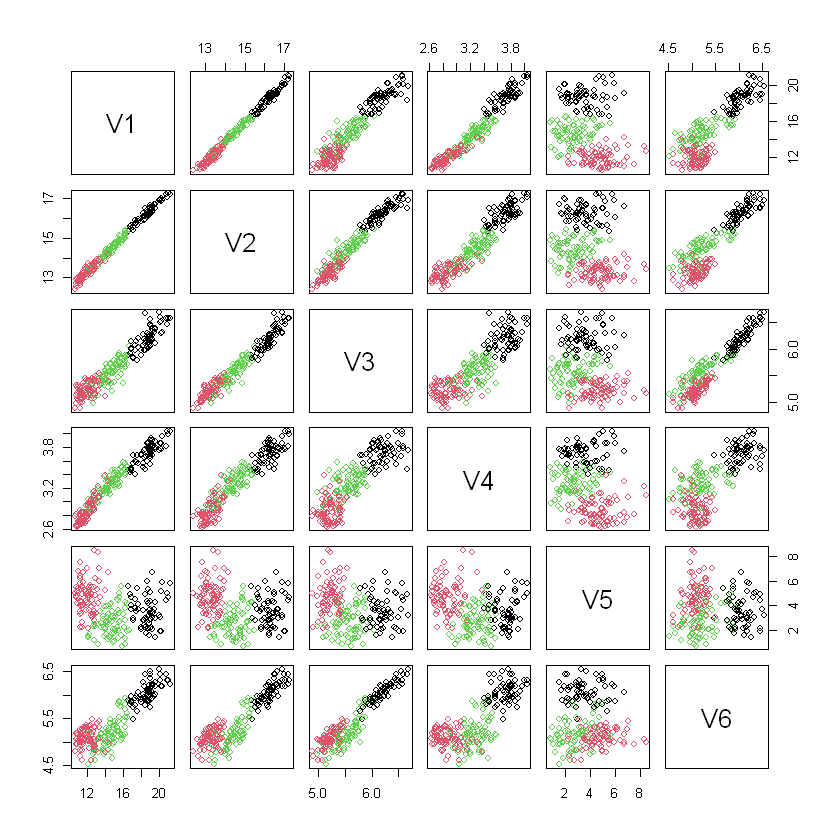

In [7]:
#ingresar valor de k0 
k_opt1 <- 3
cl<-kmeans(datos1,k_opt1,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(datos1,col=cl$cluster)

Call:
princomp(x = datos1, cor = TRUE)

Standard deviations:
    Comp.1     Comp.2     Comp.3     Comp.4     Comp.5     Comp.6 
2.16788117 1.00229308 0.49446476 0.20713724 0.08426551 0.03461094 

 6  variables and  210 observations.


,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
1,2.9205042,-0.2730151,-0.03930464,-0.04246970,0.010152392,0.007972724
2,-2.1089388,-0.5304285,-0.12243032,-0.04130075,0.002155313,0.007683248
3,-0.2189232,0.7985683,0.16423218,0.08015012,-0.010906320,-0.014971476


K-means clustering with 3 clusters of sizes 61, 77, 72

Cluster means:
        V1       V2       V3       V4       V5       V6
1 18.72180 16.29738 6.208934 3.722672 3.603590 6.066098
2 11.96442 13.27481 5.229286 2.872922 4.759740 5.088519
3 14.64847 14.46042 5.563778 3.277903 2.648931 5.192319

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  3   1   3   2   3   3   3   3   1   3   2   3   3   1   1   2   2   3   3   2 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
  2   1   3   2   2   1   2   3   3   1   3   3   2   3   1   1   1   2   3   2 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  2   2   1   3   2   1   1   2   2   2   1   2   3   2   3   3   1   3   1   2 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
  3   1   2   3   1   3   1   3   1   2   1   3   3   1   3   1   3   1   3   1 
 81  82  83  84  85  86  87  88  89  

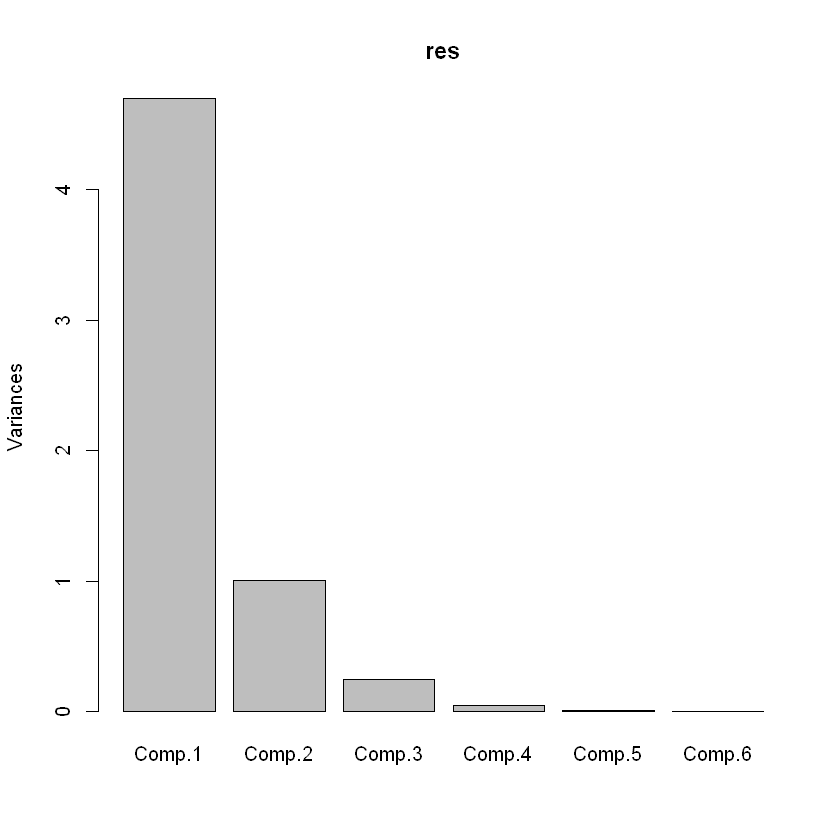

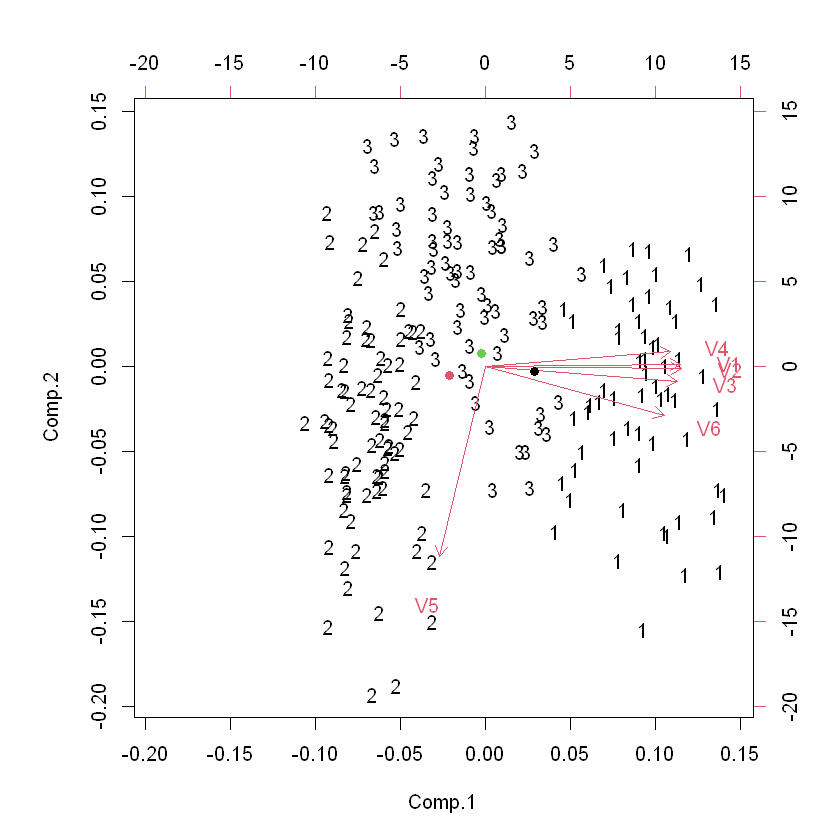

In [8]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos1, cor=TRUE)
print(res)
plot(res)
res2 <- predict(res,cl$centers)
res2
cl
biplot(res,xlabs=cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:k0,pch=19)

In [9]:
# K-means con k optimo (cambiar segun el grafico anterior)
cl1 <- kmeans(datos1, k_opt1, iter.max = 1000, nstart = 10)
cat("Centros de los grupos:\n")
print(cl1$centers)
cat("\nTamaño de los grupos:\n")
print(table(cl1$cluster))

Centros de los grupos:
        V1       V2       V3       V4       V5       V6
1 18.72180 16.29738 6.208934 3.722672 3.603590 6.066098
2 11.96442 13.27481 5.229286 2.872922 4.759740 5.088519
3 14.64847 14.46042 5.563778 3.277903 2.648931 5.192319

Tamaño de los grupos:

 1  2  3 
61 77 72 


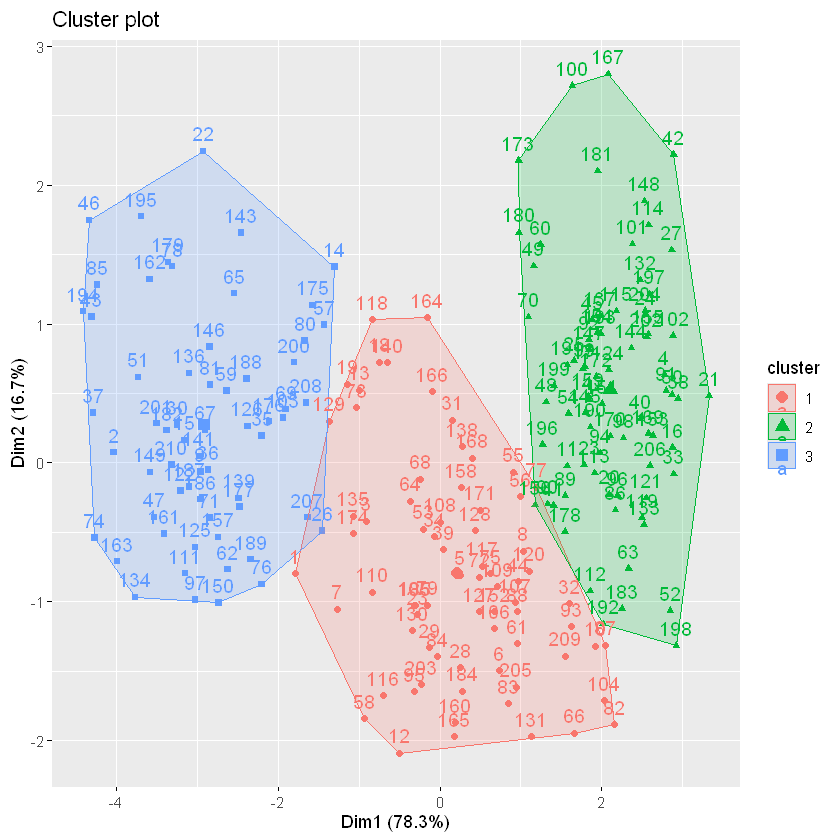

In [10]:
#install.packages("factoextra")

# 2. Load the library
library(factoextra)

df1 <- data.frame(datos1)
k0=3
cl<-kmeans(datos1,k0,iter.max=1000,nstart=10)
fviz_cluster(cl, df1)

## Ejercicio 2: Grupo16.csv
## Realice un análisis de clustering con el conjunto de datos correspondiente a su grupo, para el cual ya realizó un análisis exploratorio y de PCA (No olvide de excluir la penúltima y última columna de sus datos originales).

### Describa los datos y discuta la pertinencia de realizar un análisis de clustering o agrupamiento

   frecuencia            gasto             visitas          devoluciones    
 Min.   :-2.962738   Min.   :-6.04027   Min.   :-2.37513   Min.   :-3.3293  
 1st Qu.:-0.644700   1st Qu.:-0.51980   1st Qu.:-0.64245   1st Qu.:-0.6446  
 Median :-0.002352   Median :-0.05603   Median :-0.01972   Median :-0.1338  
 Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.647975   3rd Qu.: 0.49564   3rd Qu.: 0.54152   3rd Qu.: 0.5052  
 Max.   : 4.557919   Max.   : 5.12559   Max.   : 4.52816   Max.   : 5.9532  
 satisfaccion_cliente
 Min.   :-1.7074     
 1st Qu.:-0.6348     
 Median :-0.2656     
 Mean   : 0.0000     
 3rd Qu.: 0.3850     
 Max.   : 5.0092     

frecuencia                gasto              visitas 
                   1                    1                    1 
        devoluciones satisfaccion_cliente 
                   1                    1

frecuencia                      gasto 
-0.00000000000000016511600  0.00000000000000003968572 
                   visitas               devoluciones 
-0.00000000000000013563346 -0.00000000000000005485298 
      satisfaccion_cliente 
 0.00000000000000010149228

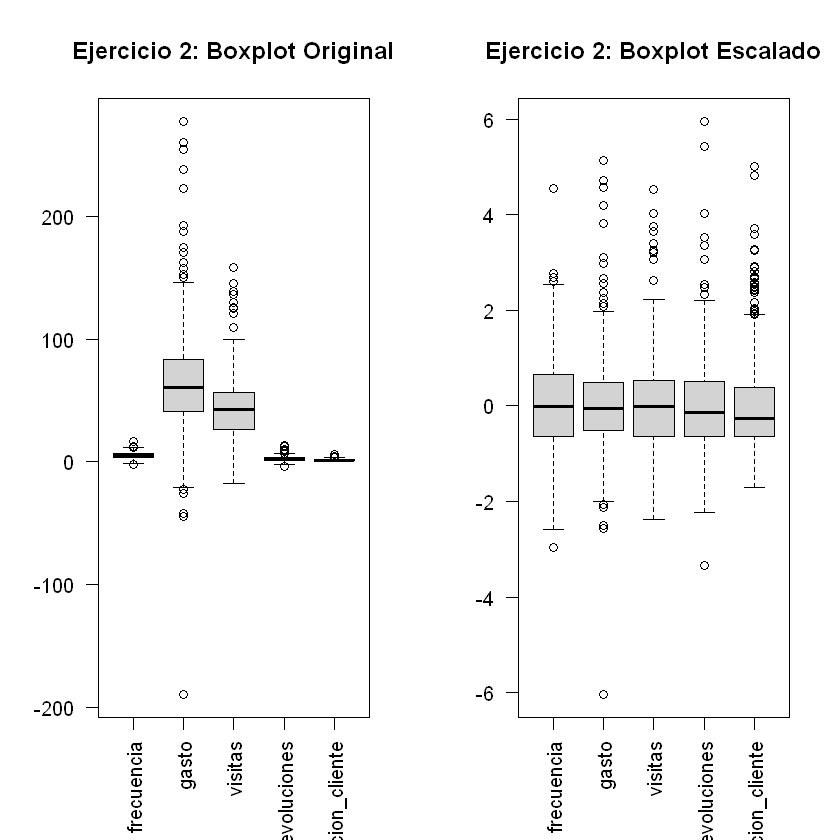

In [11]:
# Carga datos Ejercicio 2 (sin penultima y ultima columna)
datos2_raw <- read.csv("Grupo16.csv", header = TRUE, sep = ";")
datos2 <- datos2_raw[, 1:(ncol(datos2_raw) - 2)]
datos2 <- datos2[, sapply(datos2, is.numeric), drop = FALSE]
datos2 <- datos2[complete.cases(datos2), , drop = FALSE]

# Normalizacion
scaled_df2 <- apply(datos2, 2, scale)
summary(scaled_df2)
apply(scaled_df2, 2, var)
apply(scaled_df2, 2, mean)

# Grafico 1: boxplots antes y despues de normalizar
par(mfrow = c(1, 2))
boxplot(datos2, main = "Ejercicio 2: Boxplot Original", las = 2)
boxplot(scaled_df2, main = "Ejercicio 2: Boxplot Escalado", las = 2)
par(mfrow = c(1, 1))

### Utilice k-means para realizar el clustering de los datos y calcule el K óptimo.

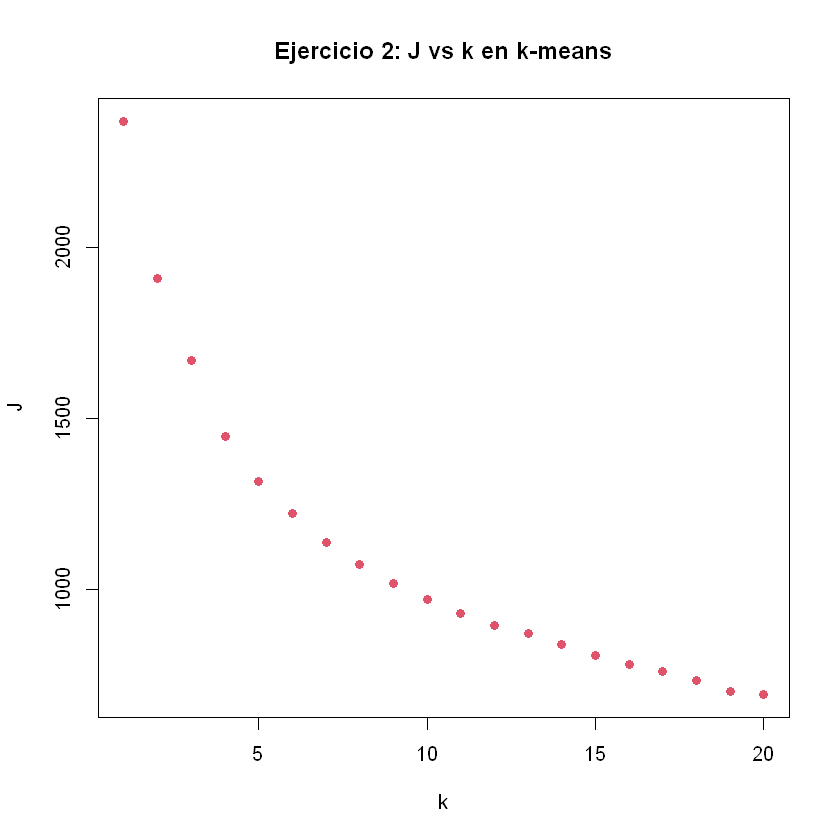

In [12]:
# Grafico J vs k para elegir k optimo
J2 <- rep(0, 20)
fin_iter2 <- 20
for (k in 1:fin_iter2) {
  cl_temp <- kmeans(scaled_df2, k, iter.max = 1000, nstart = 10)
  J2[k] <- cl_temp$tot.withinss
}
plot(1:fin_iter2, J2, xlab = "k", ylab = "J", type = "p",
     main = "Ejercicio 2: J vs k en k-means", col = 2, pch = 19)

Gráfico J vs K en K-means no indica fuerte cambio de pendiente.

Warning message:
"did not converge in 10 iterations"


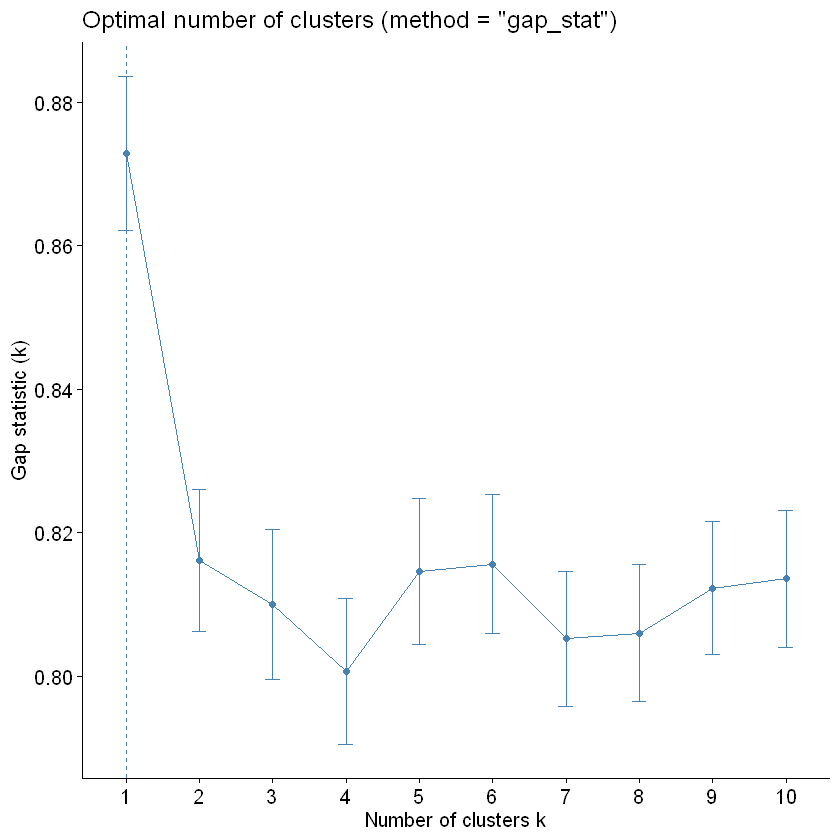

In [13]:
#calculo de gap estadístico basado en el número de grupos: 
#tasa entre la suma de distancias intragrupos con k grupos y con un sólo un grupo
df2 <- data.frame(scaled_df2)
gap_stat <- clusGap(df2,
                    FUN = kmeans,
                    nstart = 25,
                    K.max = 10,
                    B = 50)


fviz_gap_stat(gap_stat)

El método de gap statistic sugiere (k=1), indicando ausencia de grupos claramente separados.

### Caracterice los grupos obtenidos con el K óptimo. Interprete sus resultados

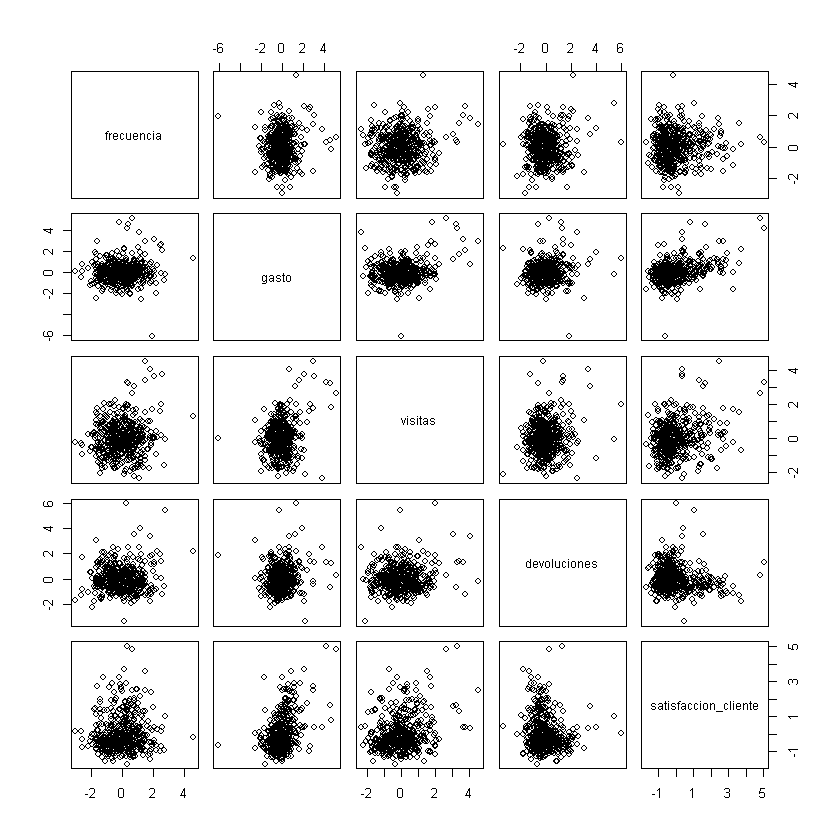

In [19]:
#ingresar valor de k0 
k0=1
cl<-kmeans(df2,k0,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(scaled_df2,col=cl$cluster)

Call:
princomp(x = scaled_df2, cor = TRUE)

Standard deviations:
   Comp.1    Comp.2    Comp.3    Comp.4    Comp.5 
1.2760722 1.0549103 0.9768187 0.8795979 0.7286541 

 5  variables and  475 observations.


ERROR: Error in scale.default(newdata, object$center, object$scale): length of 'center' must equal the number of columns of 'x'


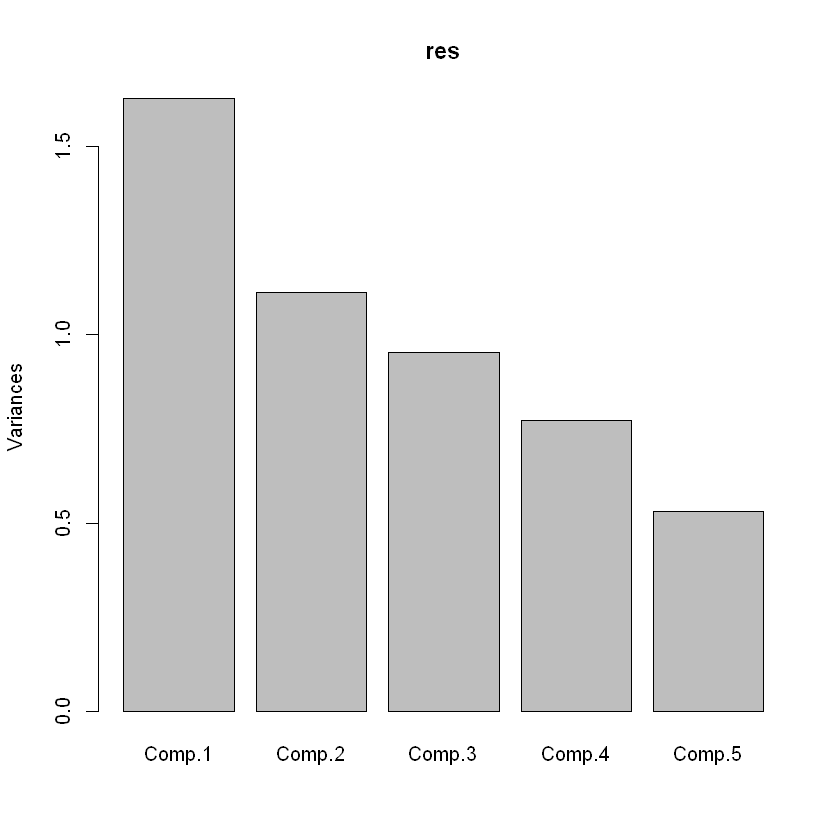

In [20]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(scaled_df2, cor=TRUE)
print(res)
plot(res)
res2 <- predict(res,cl$centers)
res2
cl
biplot(res,xlabs=cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:k0,pch=19)

In [16]:
# K-means con k optimo (cambiar segun el grafico anterior)
k_opt2 <- 1
cl2 <- kmeans(df2, k_opt2, iter.max = 1000, nstart = 10)
cat("Centros de los grupos:\n")
print(cl2$centers)
cat("\nTamano de los grupos:\n")
print(table(cl2$cluster))

Centros de los grupos:
                 frecuencia                     gasto                   visitas
1 -0.0000000000000001673515 0.00000000000000005308619 -0.0000000000000001308895
                devoluciones      satisfaccion_cliente
1 -0.00000000000000008110471 0.00000000000000007759875

Tamano de los grupos:

  1 
475 


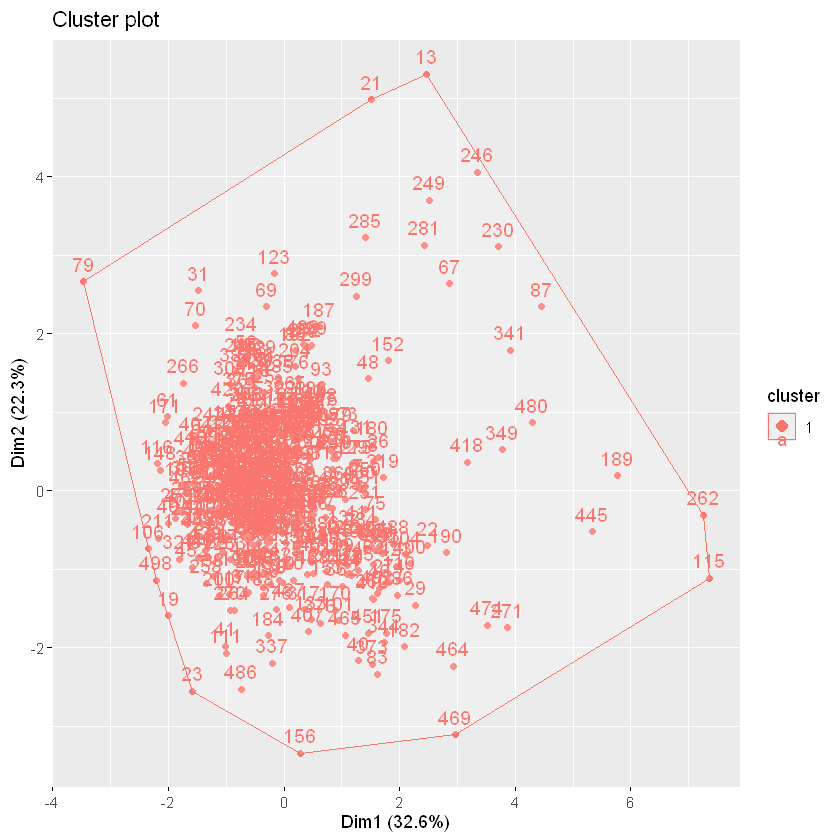

In [17]:
df2 <- data.frame(datos2)
fviz_cluster(cl2, df2)

El método de gap statistic sugiere (k=1), indicando ausencia de grupos claramente separados.

Centros de los grupos:
  frecuencia    gasto  visitas devoluciones satisfaccion_cliente
1   5.256667 99.56414 46.56226     2.501183             1.817258
2   4.943114 39.41111 40.28585     2.015225             1.240900

Tamano de los grupos:

  1   2 
186 289 


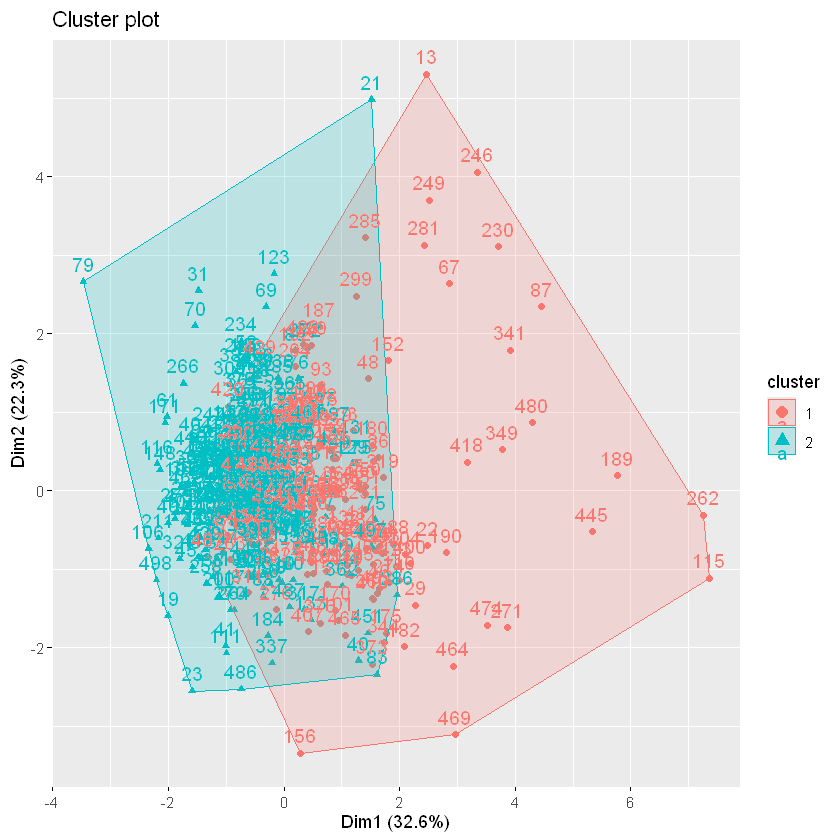

In [18]:
# K-means con k optimo (cambiar segun el grafico anterior)
k_opt2 <- 2
cl2 <- kmeans(df2, k_opt2, iter.max = 1000, nstart = 10)
cat("Centros de los grupos:\n")
print(cl2$centers)
cat("\nTamano de los grupos:\n")
print(table(cl2$cluster))

df2 <- data.frame(datos2)
fviz_cluster(cl2, df2)